In [ ]:
import numpy as np                     # Numerical programming package
import matplotlib.pyplot as plt        # Plotting library
import scipy as sci                    # Scientific computing library
from scipy import constants as scicost # Physical and Mathematical constants
from tqdm import tqdm                  # A progress bar (interesting note: tqdm means "progress" in Arabic (taqadum, تقدّم))

# Units normalization
As in many Particle-In-Cell codes we adopt the following normalization conventions:

- Angular frequencies are normalized w.r.t an arbitrary $\omega_R$
- Times are normalized w.r.t. $T_R = 1/\omega_R$
- Lengths are normalized w.r.t. $L_R = c / \omega_R$
- Electric fields are normalized w.r.t. $E_R = {{m_e c \omega_R} \over {e}}$
- Magnetic fields are normalized w.r.t. $B_R = {{m_e \omega_R} \over {e}}$
- Number densities are normalized w.r.t. $N_R = {{\epsilon_0 m_e \omega_R^2} \over {e_0^2}}$
- Current densities are normalized w.r.t. $j_R = c e_0 N_R$
- Electric charge is normalized w.r.t. $e_r = e_0$
- Mass is normalized w.r.t. $m_R = m_e$

Note that with this choice the speed of light is equal to 1

___

# Maxwell solver

### Maxwell's equations
With the above normalization, Maxwell's equations become:

$\nabla \cdot \mathbf{E} = \rho$  
$\nabla \cdot \mathbf{B} = 0$  
$\nabla \times \mathbf{E} = -\partial_t \mathbf{B}$  
$\nabla \times \mathbf{B} = \mathbf{j} + \partial_t \mathbf{E}$  

which in 1D means (with some re-ordering):  
$\partial_x E_x = \rho $  
$\partial_x B_x = 0 $  
$\partial_t B_x = 0 $   
$\partial_t B_y = \partial_x E_z$  
$\partial_t B_z = -\partial_x E_y$  
$\partial_t E_x = -j_x $    
$\partial_t E_y = -j_y - \partial_x B_z$   
$\partial_t E_z = -j_z + \partial_x B_y$

### Yee lattice
In order to achieve second-order accuracy in time and space, we use the so-called "Yee lattice". We introduce a staggering in space an time that leads to centered derivatives everywhere in the discretized equations.
More specifically, we use the following staggering:  
$E^{(n)}_x(i+1/2)$  
$E^{(n)}_y(i)$  
$E^{(n)}_z(i)$  
$B^{(n+1/2)}_x(i)$  
$B^{(n+1/2)}_y(i+1/2)$  
$B^{(n+1/2)}_z(i+1/2)$  
$j^{(n+1/2)}_x(i+1/2)$  
$j^{(n+1/2)}_y(i)$  
$j^{(n+1/2)}_z(i)$  
$\rho^{(n)}(i)$  

Note that we only need to consider the density $\rho$ at the initial time, and that $B_x$ stays constant.

In [ ]:
##########################################
#                                        #
# Code to be used for the following      #
# exercises. Please modify it here       #
#                                        #
##########################################

class EM1D:
    '''
    This class stores the EM field components and provides methods to initialize and update the fields
    '''

    def __init__(self, N_cells, x0, x1):
        '''
        This function initializes the simulation box and allocates field data.
        N_cells is the number of physical cells. We are introducing additional "guard cells"
        on the left and on the right. For this application we only need one guard cell on the left
        for the magnetic field and one on the right for the electric field,
        in order to deal with boundary conditions cleanly.
        x0 is the coordinate of the first grid point of the EM field. x1 is the coordinate of the
        first guard cell on the right. The following "figure" should clarify these choices:

        [x]   0    X    0    X    0    X    0    X   [0]
              ^                                       ^
             x_0                                     x_1

        0 : integer points
        X : half-integer points
        [X] or [0]: guard cells
        '''
        self.N = N_cells + 1
        self.x0 = x0
        self.x1 = x1
        self.dx = (x1-x0)/N_cells
        self.xx = np.linspace(
            self.x0,
            self.x1,
            self.N) #integer coords (including guard cells)
        self.xxh = self.xx - self.dx*0.5 #half-integer coordinates (including guard cells)

        self.Ex = np.zeros(self.N)
        self.Ey = np.zeros(self.N)
        self.Ez = np.zeros(self.N)
        self.Bx = np.zeros(self.N)
        self.By = np.zeros(self.N)
        self.Bz = np.zeros(self.N)


    def init_Ex_with_density(self,rho):
        '''
        This function initializes E_x using the initial density.
        The user must ensure that sum(rho) ~ 0 (i.e., global neutrality)
        '''
        self.Ex[1:] = np.cumsum(rho*self.dx)


    def get_coords_without_guard_cells(self):
        return (
            self.xx[0:-1],
            self.xxh[1:])


    def get_fields_without_guard_cells(self):
        return (self.Ex[1:],
                self.Ey[0:-1],
                self.Ez[0:-1],
                self.Bx[0:-1],
                self.By[1:],
                self.Bz[1:])

    def advance_E(self, dt, jx, jy, jz):
        '''
        This function evolves the magnetic field by dt, using the current components jx, jy, jz
        '''
        self.Ey[0:-1] = self.Ey[0:-1] - (dt/self.dx)*np.diff(self.Bz)
        self.Ez[0:-1] = self.Ez[0:-1] + (dt/self.dx)*np.diff(self.By)

        if jx is not None :
            self.Ex[0:-1] = self.Ex[0:-1] - jx*dt
        if jy is not None :
            self.Ey[0:-1] = self.Ey[0:-1] - jy*dt
        if jz is not None :
            self.Ez[0:-1] = self.Ez[0:-1] - jz*dt

    def advance_B(self, dt):
        '''
        This function evolves the magnetic field by dt
        '''

        # no need to evolve Bx

        ### ADD YOUR CODE HERE ####
        self.By[1:] = self.By[1:] # + ?
        self.Bz[1:] = self.Bz[1:] # + ?
        ###########################

        #######SOLUTION############
        self.By[1:] = self.By[1:] + (dt/self.dx)*np.diff(self.Ez)
        self.Bz[1:] = self.Bz[1:] - (dt/self.dx)*np.diff(self.Ey)
        ###########################

    def set_transverse_fields(self, Eyf, Ezf, Byf, Bzf):
        '''
        This function sets the transverse fields given some functors
        '''
        if Eyf is not None :
            self.Ey[0:-1] = Eyf(self.xx[0:-1])
        if Ezf is not None :
            self.Ez[0:-1] = Ezf(self.xx[0:-1])
        if Byf is not None :
            self.By[1:] = Byf(self.xxh[1:])
        if Bzf is not None :
            self.Bz[1:] = Bzf(self.xxh[1:])

    def apply_E_boundary(self, bondary_type, dt = None):
        '''
        This function applies boundary conditions to the E field
        '''
        if (bondary_type == "reflective"):
            pass # do nothing
        elif (bondary_type == "periodic"):

            ### ADD YOUR CODE HERE ####
            # self.Ey[-1] = ?
            # self.Ez[-1] = ?
            ###########################

            #######SOLUTION############
            self.Ey[-1] = self.Ey[0]
            self.Ez[-1] = self.Ez[0]
            ###########################
            pass

        elif (bondary_type == "open"):

            assert(dt != None)
            dt_over_dx = (dt/self.dx)

            ### ADD YOUR CODE HERE ####
            # self.Ey[-1] = ?
            # self.Ez[-1] = ?
            ###########################

            #######SOLUTION############
            self.Ey[-1] = (2*self.Bz[-1] + (dt_over_dx-1)*self.Ey[-2])/(1+dt_over_dx)
            self.Ez[-1] = (-2*self.By[-1] + (dt_over_dx-1)*self.Ez[-2])/(1+dt_over_dx)
            ###########################
            pass

        else:
            raise Exception("Sorry, no boundary condition with this name")


    def apply_B_boundary(self, bondary_type, dt = None):
        '''
        This function applies boundary conditions to the B field
        '''
        if (bondary_type == "reflective"):
            pass # do nothing
        elif (bondary_type == "periodic"):

            ### ADD YOUR CODE HERE ####
            #self.By[0] = ?
            #self.Bz[0] = ?
            ###########################

            #######SOLUTION############
            self.By[0] = self.By[-1]
            self.Bz[0] = self.Bz[-1]
            ###########################
            pass

        elif (bondary_type == "open"):

            assert(dt != None)
            dt_over_dx = (dt/self.dx)

            ### ADD YOUR CODE HERE ####
            # self.By[0] = ?
            # self.Bz[0] = ?
            ###########################

            #######SOLUTION############
            self.By[0] = (+2*self.Ez[0] + (dt_over_dx-1)*self.By[1])/(1+dt_over_dx)
            self.Bz[0] = (-2*self.Ey[0] + (dt_over_dx-1)*self.Bz[1])/(1+dt_over_dx)
            ###########################
            pass

        else:
            raise Exception("Sorry, no boundary condition with this name")

### Exercise 1 : Yee FTDT EM solver

The python class EM1D implements a simple 1D Maxwell solver. The solver is incomplete. Please complete the solver by implementing the equation for the evolution of the magnetic field and test it by running the function `do_test_ex_yee` and checking the result.

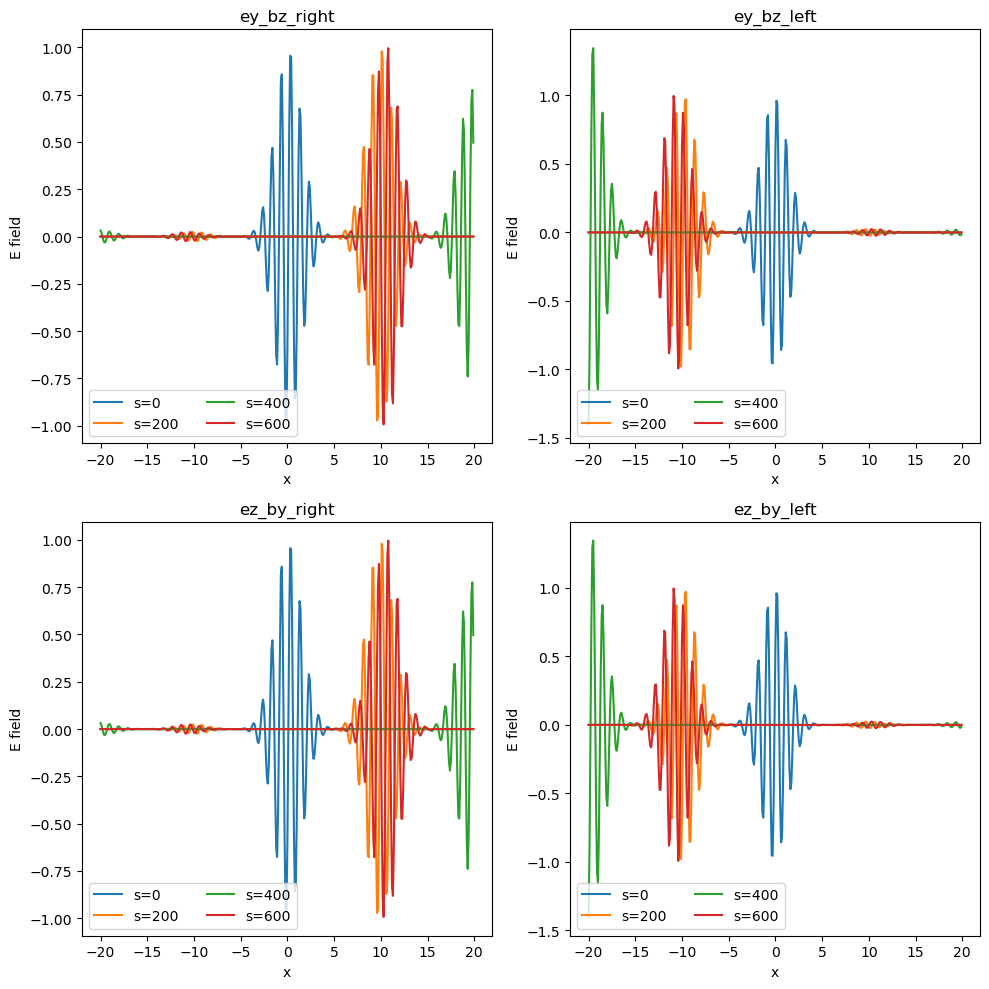

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def t_ex_yee(test_type, ax):
    N = 400
    xl = -20.0
    xr = 20.0
    cfl = 0.98

    em1d = EM1D(N, xl, xr)

    dt = cfl * em1d.dx

    cc = 0
    if (test_type == "ey_bz_left"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ey_bz_right"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ez_by_left"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    elif (test_type == "ez_by_right"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    else:
        raise Exception("Sorry, no case with this name")

    em1d.apply_E_boundary("reflective")
    em1d.apply_B_boundary("reflective")

    em1d.advance_B(dt*0.5)
    F_saved = []

    steps = 400

    for i in range(steps):
        em1d.advance_E(dt, None, None, None)
        em1d.apply_E_boundary("reflective")
        em1d.advance_B(dt)
        em1d.apply_B_boundary("reflective")
        if (i%100 == 0):
            F_saved.append(np.copy(em1d.get_fields_without_guard_cells()[cc]))

    ax.set_title(test_type)
    ax.set_xlabel("x")
    ax.set_ylabel("E field")
    for i, F in enumerate(F_saved):
        ax.plot(em1d.get_coords_without_guard_cells()[0], F, label="s={:d}".format(i*200))
    ax.legend(loc="lower left", ncol=2)

def do_test_ex_yee():
    fig, ax = plt.subplots(2,2, figsize=(10,10))

    t_ex_yee("ey_bz_right", ax[0,0])
    t_ex_yee("ey_bz_left", ax[0,1])
    t_ex_yee("ez_by_right", ax[1,0])
    t_ex_yee("ez_by_left", ax[1,1])

    plt.tight_layout()
    plt.show()

do_test_ex_yee()

### Exercise 2 : periodic boundary conditions

The EM1D class implemented  this Notebook only provides reflective boundary conditions. Complete the code to implement the"periodic" boundary conditions. Periodic boundary conditions can be imposed by setting the guard cell on the left equal to the "real" point on the right and vice-versa. Please test periodic boundaries by running the function `do_test_ex_periodic` and checking the result.

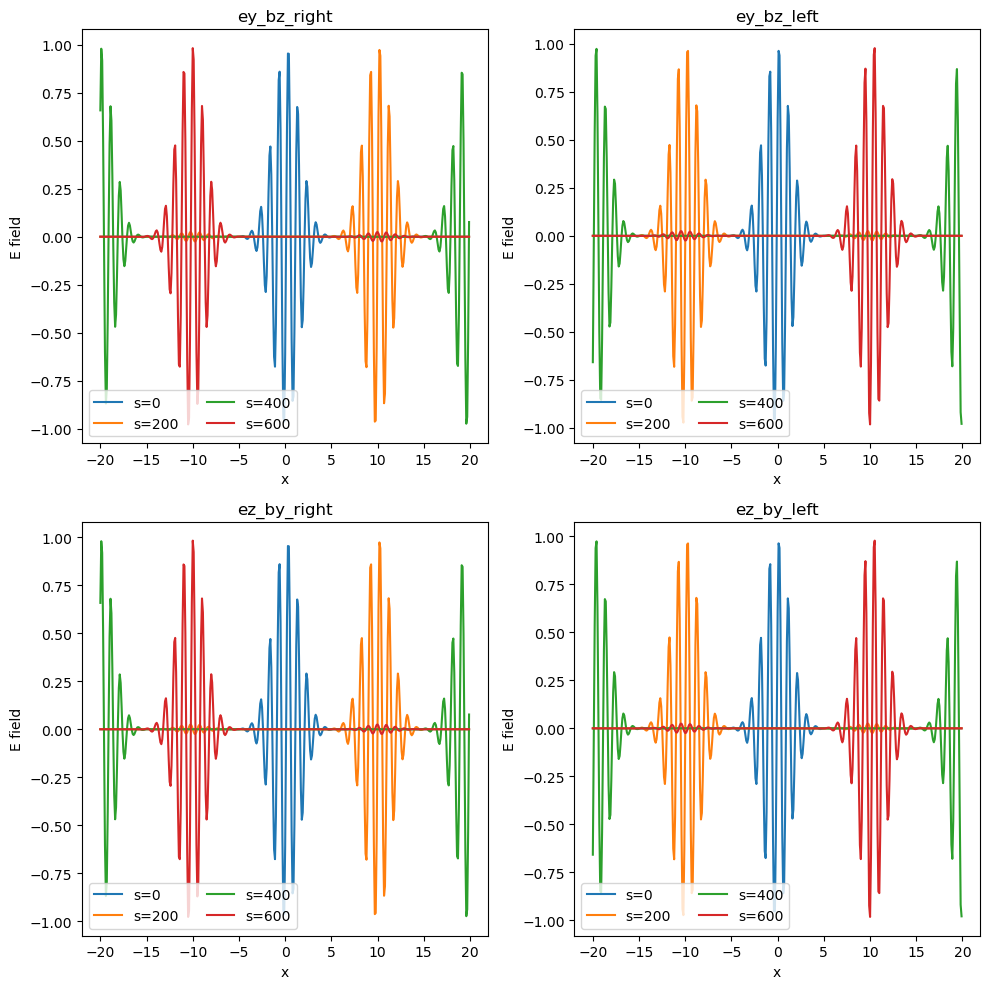

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def t_ex_periodic(test_type, ax):
    N = 400
    xl = -20.0
    xr = 20.0
    cfl = 0.99

    em1d = EM1D(N, xl, xr)

    dt = cfl * em1d.dx

    cc = 0
    if (test_type == "ey_bz_left"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ey_bz_right"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ez_by_left"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    elif (test_type == "ez_by_right"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    else:
        raise Exception("Sorry, no case with this name")

    em1d.apply_E_boundary("periodic")
    em1d.apply_B_boundary("periodic")

    em1d.advance_B(dt*0.5)
    F_saved = []

    steps = 400

    for i in range(steps):
        em1d.advance_E(dt, None, None, None)
        em1d.apply_E_boundary("periodic")
        em1d.advance_B(dt)
        em1d.apply_B_boundary("periodic")
        if (i%100 == 0):
            F_saved.append(np.copy(em1d.get_fields_without_guard_cells()[cc]))

    ax.set_title(test_type)
    ax.set_xlabel("x")
    ax.set_ylabel("E field")
    for i, F in enumerate(F_saved):
        ax.plot(em1d.get_coords_without_guard_cells()[0], F, label="s={:d}".format(i*200))
    ax.legend(loc="lower left", ncol=2)

def do_test_ex_periodic():
    fig, ax = plt.subplots(2,2, figsize=(10,10))

    t_ex_periodic("ey_bz_right", ax[0,0])
    t_ex_periodic("ey_bz_left", ax[0,1])
    t_ex_periodic("ez_by_right", ax[1,0])
    t_ex_periodic("ez_by_left", ax[1,1])

    plt.tight_layout()
    plt.show()

do_test_ex_periodic()

### Exercise 3 : open boundary conditions
The EM1D class implemented  this Notebook only provides reflective boundary conditions. Complete the code to implement the "open" boundary conditions. Please test Open boundaries by running the function `do_test_ex_open` and checking the result.

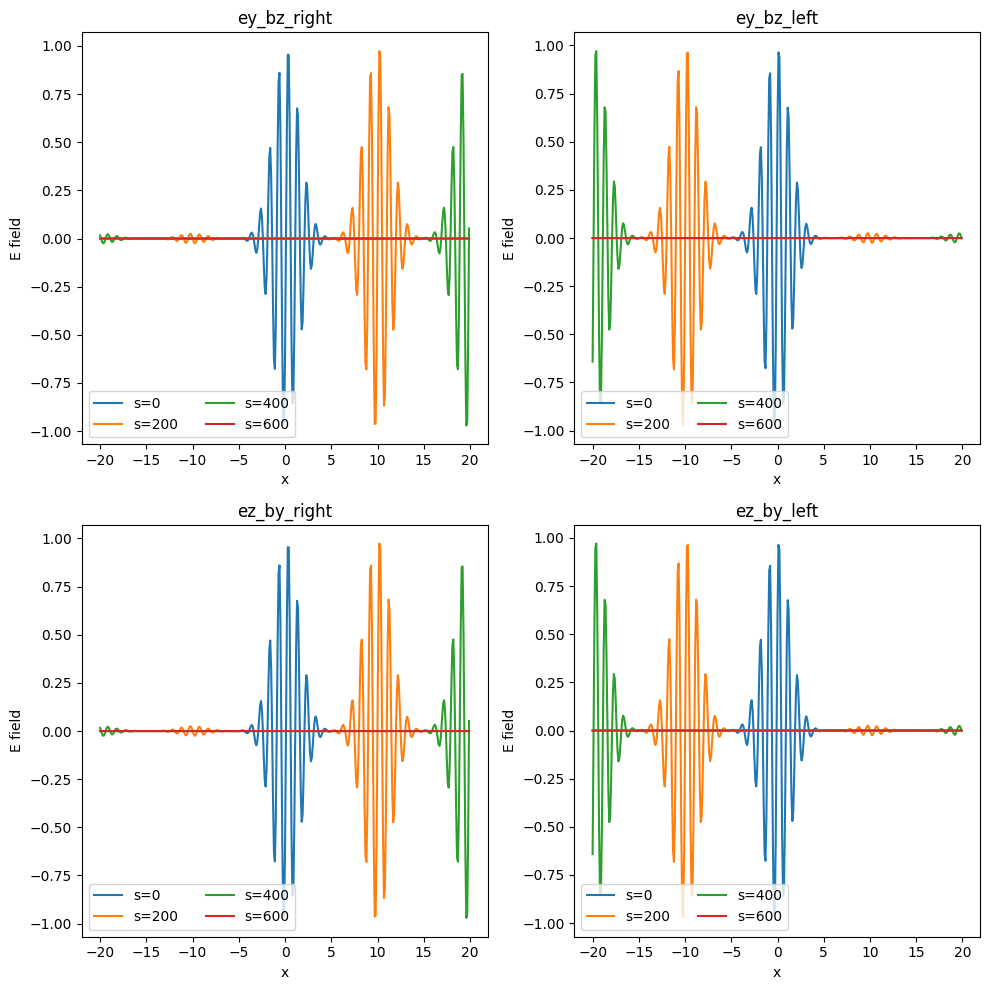

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def t_ex_open(test_type, ax):
    N = 400
    xl = -20.0
    xr = 20.0
    cfl = 0.99

    em1d = EM1D(N, xl, xr)

    dt = cfl * em1d.dx

    cc = 0
    if (test_type == "ey_bz_left"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ey_bz_right"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ez_by_left"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    elif (test_type == "ez_by_right"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    else:
        raise Exception("Sorry, no case with this name")

    em1d.apply_E_boundary("open", dt)
    em1d.apply_B_boundary("open", dt)

    em1d.advance_B(dt*0.5)
    F_saved = []

    steps = 400

    for i in range(steps):
        em1d.advance_E(dt, None, None, None)
        em1d.apply_E_boundary("open", dt)
        em1d.advance_B(dt)
        em1d.apply_B_boundary("open", dt)
        if (i%100 == 0):
            F_saved.append(np.copy(em1d.get_fields_without_guard_cells()[cc]))

    ax.set_title(test_type)
    ax.set_xlabel("x")
    ax.set_ylabel("E field")
    for i, F in enumerate(F_saved):
        ax.plot(em1d.get_coords_without_guard_cells()[0], F, label="s={:d}".format(i*200))
    ax.legend(loc="lower left", ncol=2)

def do_test_ex_open():
    fig, ax = plt.subplots(2,2, figsize=(10,10))

    t_ex_open("ey_bz_right", ax[0,0])
    t_ex_open("ey_bz_left", ax[0,1])
    t_ex_open("ez_by_right", ax[1,0])
    t_ex_open("ez_by_left", ax[1,1])

    plt.tight_layout()
    plt.show()

do_test_ex_open()

### Exercise 4 : the CFL condition
Carry out a Von Neumann analysis of this solver. Suppose that $E(x,t) = \mp B(x,t) = A e^{i(\omega t \mp k x)}$ for waves propagating along +x or -x. Derive the dispersion relation and the group veolocity $\omega/k$, and plot them.

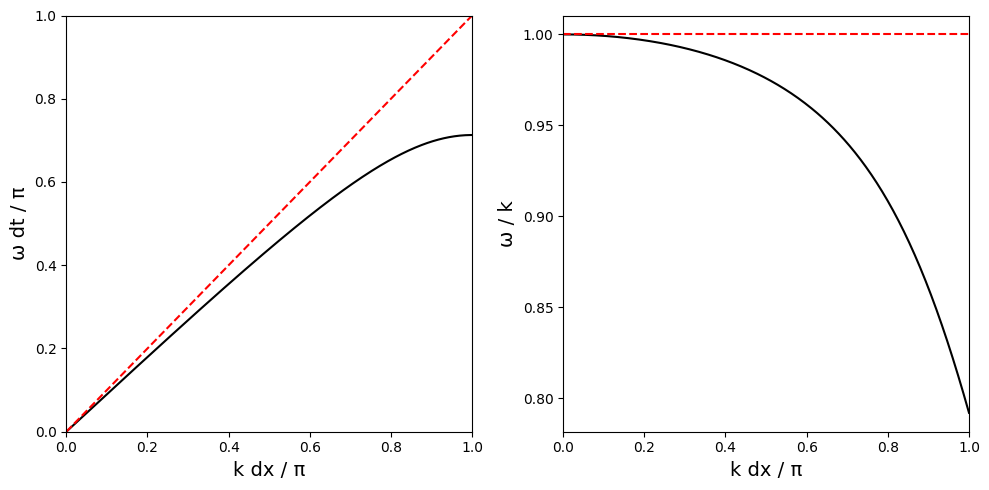

In [ ]:

def plot_cfl():
    # Représentation de la vitesse de phase en fonction des paramètres numériques
    cfl = 0.9  #dt_over_dx
    k_times_dx = np.linspace(0.001,np.pi,300)

    ### ADD YOUR CODE HERE ####
    # omega_times_dt = ?
    # v_phase = ?
    ###########################

    ### SOLUTION ##############
    omega_times_dt = 2*np.arcsin(cfl*np.sin(k_times_dx/2))
    v_phase = omega_times_dt/k_times_dx/cfl
    ###########################

    fig, ax = plt.subplots(1,2, figsize=(10,5))

    ax[0].plot(k_times_dx/np.pi, omega_times_dt/np.pi,'k')
    ax[0].plot(k_times_dx/np.pi, k_times_dx/np.pi,'r--')
    ax[0].set_xlabel('k dx / π',fontsize=14)
    ax[0].set_ylabel("ω dt / π",fontsize=14)
    ax[0].set_xlim(0,1)
    ax[0].set_ylim(0,1)

    ax[1].plot(k_times_dx/np.pi, v_phase,'k')
    ax[1].plot(k_times_dx/np.pi, np.ones(k_times_dx.shape),'r--')
    ax[1].set_xlabel('k dx / π',fontsize=14)
    ax[1].set_ylabel("ω / k",fontsize=14)
    ax[1].set_xlim(0,1)

    plt.tight_layout()

plot_cfl()

Now, starting either with exercise 1 or 2, try to see what happens if you set the CFL number slightly above 1, e.g. CFL=1.01.

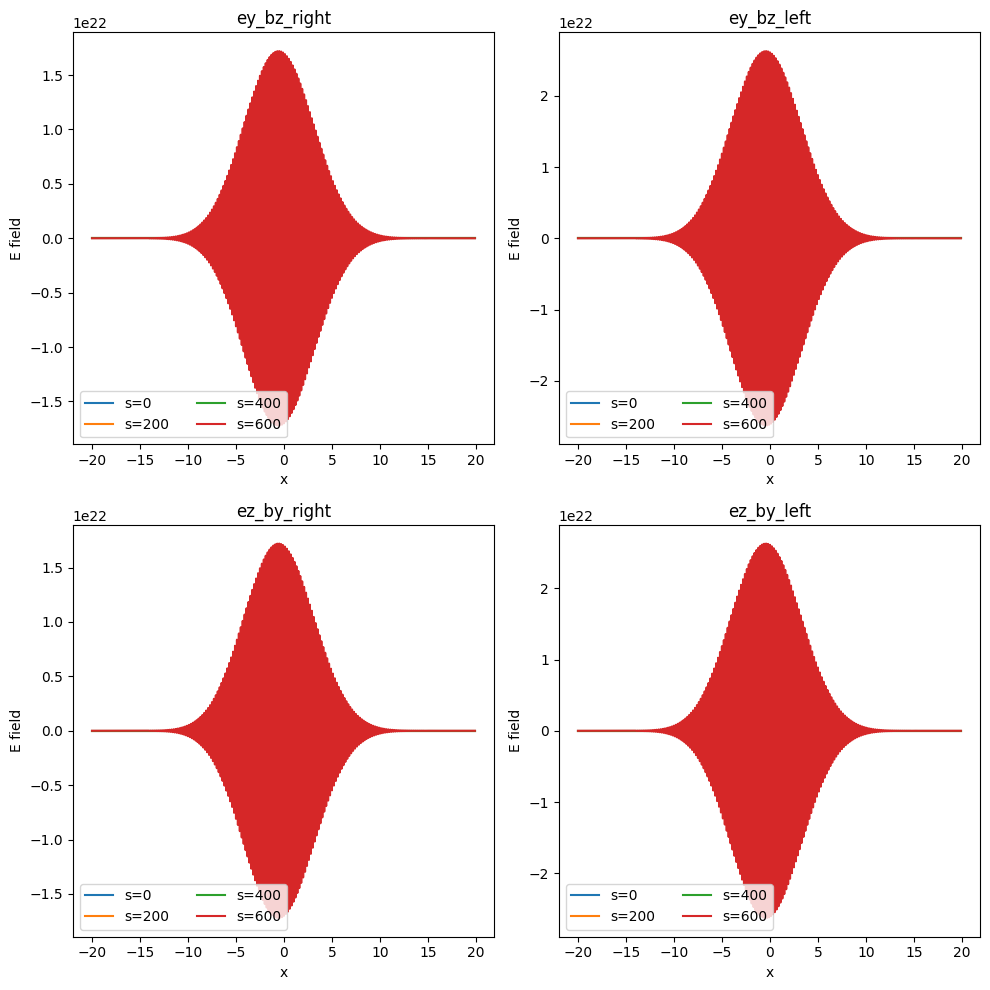

In [ ]:
#############################
# COPY THE CODE OF M1 or M2 #
# HERE AND MODIFY IT        #
#############################

##### EXAMPLE WITH EXERCISE 2 #####

def t_ex_periodic_mod (test_type, ax):
    N = 400
    xl = -20.0
    xr = 20.0
    cfl = 1.01

    em1d = EM1D(N, xl, xr)

    dt = cfl * em1d.dx

    cc = 0
    if (test_type == "ey_bz_left"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ey_bz_right"):
        em1d.set_transverse_fields(
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None,
           None,
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2))
        cc = 1
    elif (test_type == "ez_by_left"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: +np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    elif (test_type == "ez_by_right"):
        em1d.set_transverse_fields(
           None,
           lambda x: np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           lambda x: -np.sin(2.0*np.pi*x)*np.exp(-(x/2.0)**2),
           None)
        cc = 2
    else:
        raise Exception("Sorry, no case with this name")

    em1d.apply_E_boundary("periodic")
    em1d.apply_B_boundary("periodic")

    em1d.advance_B(dt*0.5)
    F_saved = []

    steps = 400

    for i in range(steps):
        em1d.advance_E(dt, None, None, None)
        em1d.apply_E_boundary("periodic")
        em1d.advance_B(dt)
        em1d.apply_B_boundary("periodic")
        if (i%100 == 0):
            F_saved.append(np.copy(em1d.get_fields_without_guard_cells()[cc]))

    ax.set_title(test_type)
    ax.set_xlabel("x")
    ax.set_ylabel("E field")
    for i, F in enumerate(F_saved):
        ax.plot(em1d.get_coords_without_guard_cells()[0], F, label="s={:d}".format(i*200))
    ax.legend(loc="lower left", ncol=2)

def do_test_ex_periodic_mod():
    fig, ax = plt.subplots(2,2, figsize=(10,10))

    t_ex_periodic_mod("ey_bz_right", ax[0,0])
    t_ex_periodic_mod("ey_bz_left", ax[0,1])
    t_ex_periodic_mod("ez_by_right", ax[1,0])
    t_ex_periodic_mod("ez_by_left", ax[1,1])

    plt.tight_layout()
    plt.show()

do_test_ex_periodic_mod()

### Exercise 5 : use an antenna to generate a laser pulse
Using this solver, provide a runnable example in which a finite-time electromagnetic wave is injected into the simulation box using an antenna. The antenna should be a transverse oscillating current whose envelope starts and zero, rises smoothly, peaks, and then decreases smoothly to zero. Spatially, the antenna should be one or few grid points wide. You could modify the code below to achieve this.
Injecting an electromagnetic wave with an antenna is generally preferable with respect to initializing the field on the grid.

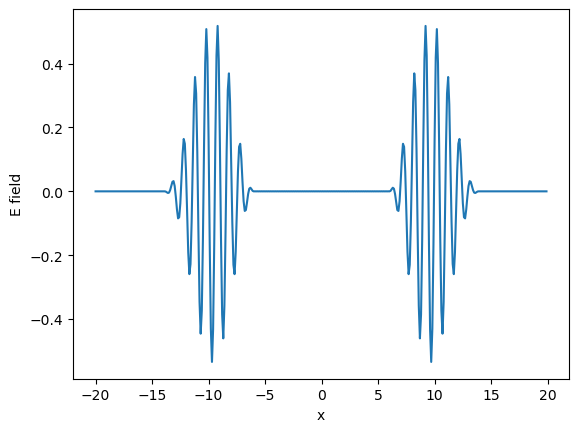

In [ ]:
def do_antenna_test():
    N = 400
    xl = -20.0
    xr = 20.0
    cfl = 1.0

    em1d = EM1D(N, xl, xr)

    dt = cfl * em1d.dx

    steps = 200

    for i in range(steps):
        xx = em1d.get_coords_without_guard_cells()[0]

        #### YOUR CODE HERE
        # Modify this "antenna" function to inject an electromangetic wave in the simulation
        def jy(t):
            return 0.0
        ###################

        ##### POSSIBLE SOLUTION #####
        l_peak = 10.0
        l_duration = 8.0
        l_wavelength = 1.0
        def jy (t):
            return t*np.sin(2.0*np.pi*t/l_wavelength)*(np.abs(t-l_peak)<l_duration/2)*(np.cos(np.pi*(t-l_peak)/l_duration))**2

        ###############################
        em1d.advance_E(dt, None, np.where(xx==xx[N//2],jy(i*dt),0.0), None)
        em1d.apply_E_boundary("periodic")
        em1d.advance_B(dt)
        em1d.apply_B_boundary("periodic")


    fig, ax = plt.subplots(1)
    ax.set_xlabel("x")
    ax.set_ylabel("E field")
    ax.plot(em1d.get_coords_without_guard_cells()[0], em1d.get_fields_without_guard_cells()[1])

do_antenna_test()

### Exercise 6 : a 2D Yee FDTD Maxwell solver

In 2D Maxwell's equations read as follows (with some re-ordering):


$\partial_x E_x + \partial_y E_y = \rho $  
$\partial_x B_x + \partial_y B_y = 0 $  
$\partial_t B_x = -\partial_y E_z $   
$\partial_t B_y = \partial_x E_z$  
$\partial_t B_z = \partial_y E_x - \partial_x E_y$  
$\partial_t E_x = -j_x + \partial_y B_z$    
$\partial_t E_y = -j_y - \partial_x B_z$   
$\partial_t E_z = -j_z + \partial_x B_y - \partial_y B_z$

In this exercise you will implement a function to evolve $\mathbf{B}$ from step $n - 1/2$ to step $n + 1/2$, and $\mathbf{E}$ from step $n$ to step $n+1$, given the electric current $\mathbf{J}$ at time $n+1/2$. Assume one guard cell on the left for half-integer co-ordinates and one guard cell on the right for integer co-ordinates. Please run `do_maxwell_2d_test` to check the result. The test should generate an electromagnetic wave in a box via an oscillating current (reflective boundary conditions are implemented). Case 1 is a dipole oscillating along x, case 2 is a dipole oscillating along y, and case 3 is a dipole oscillating along z. In all three cases the dipole is at the center of the box.

Remember that in 2D fields and currents are staggered as follows:

$E^{(n)}_x(i+1/2, j)$  
$E^{(n)}_y(i, j+1/2)$  
$E^{(n)}_z(i, j)$  
$B^{(n+1/2)}_x(i, j+1/2)$  
$B^{(n+1/2)}_y(i+1/2, j)$  
$B^{(n+1/2)}_z(i+1/2, j+1/2)$  
$j^{(n+1/2)}_x(i+1/2, j)$  
$j^{(n+1/2)}_y(i, j+1/2)$  
$j^{(n+1/2)}_z(i, j)$

In [ ]:
def evolve_E_B(Ex, Ey, Ez, Bx, By, Bz, Jx, Jy, Jz, dx, dy, dt):

    #### YOUR CODE HERE ###########
    # note : use np.diff(F[:,?], axis=0)/dx and np.diff(F[?,:], axis=1)/dy
    # for dF/dx and dF/dy derivatives!
    # Bx[0:-1 , 1:  ] += ?
    # By[1:   , 0:-1] += ?
    # Bz[1:   , 1:  ] += ?
    # Ex[1:   , 0:-1] += ?
    # Ey[0:-1 , 1:  ] += ?
    # Ez[0:-1 , 0:-1] += ?
    ###############################

    #### SOLUTION ###########
    Bx[0:-1 , 1:  ] += dt*( - np.diff(Ez[0:-1,:   ], axis=1)/dy )
    By[1:   , 0:-1] += dt*( + np.diff(Ez[ :  ,0:-1], axis=0)/dx )
    Bz[1:   , 1:  ] += dt*( + np.diff(Ex[1:  , :  ], axis=1)/dy - np.diff(Ey[:   ,1:], axis=0)/dx )
    Ex[1:   , 0:-1] += dt*( + np.diff(Bz[1:  , :  ], axis=1)/dy                                   - Jx[1:   , 0:-1] )
    Ey[0:-1 , 1:  ] += dt*( - np.diff(Bz[ :  ,1:  ], axis=0)/dx                                   - Jy[0:-1 , 1:  ] )
    Ez[0:-1 , 0:-1] += dt*( + np.diff(By[ :  ,0:-1], axis=0)/dx - np.diff(Bx[0:-1, :], axis=1)/dy - Jz[0:-1 , 0:-1] )
    ###############################

    return Ex, Ey, Ez, Bx, By, Bz

Simulation 1/3


100%|████████████████████████████████████████| 100/100 [00:00<00:00, 244.81it/s]


Simulation 2/3


100%|████████████████████████████████████████| 100/100 [00:00<00:00, 303.44it/s]


Simulation 3/3


100%|████████████████████████████████████████| 100/100 [00:00<00:00, 350.34it/s]


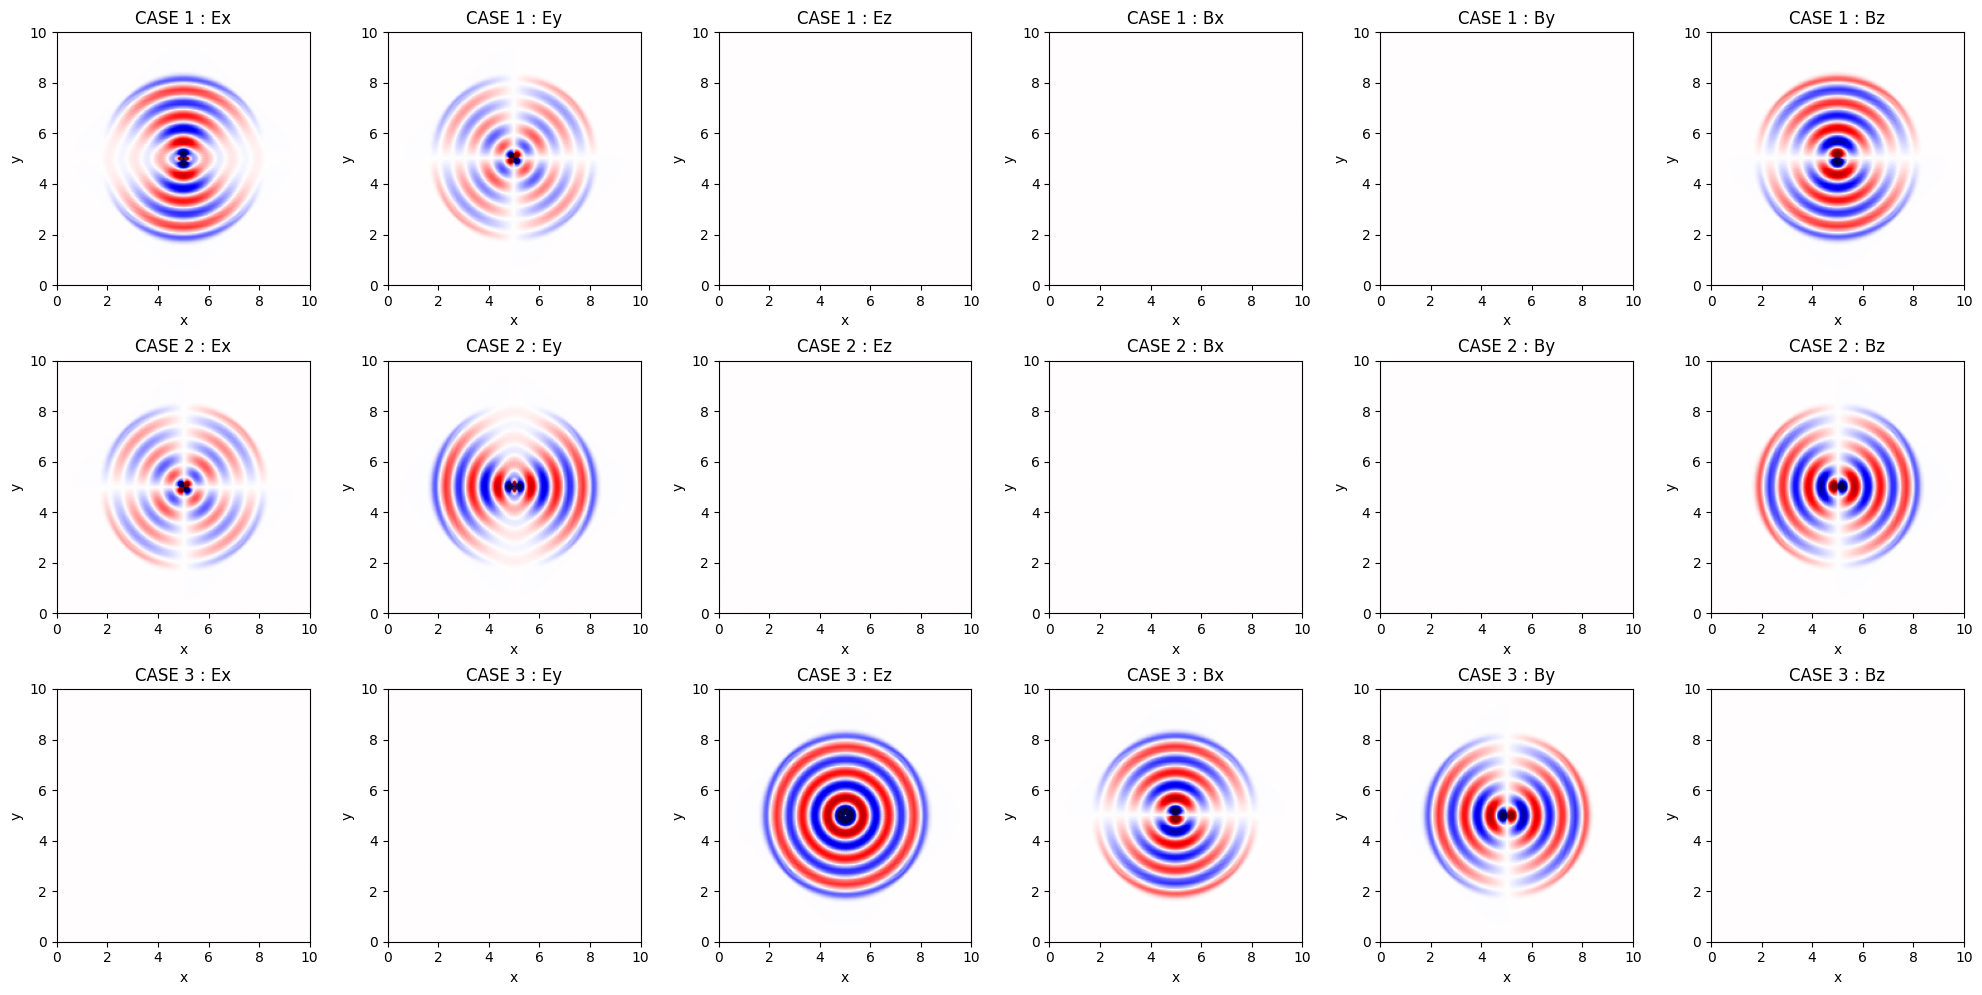

In [ ]:
###########################
# DO NOT MODIFY THIS CELL #
###########################

def init_zero (Nx, Ny):
    Ex = np.zeros([Nx, Ny])
    Ey = np.zeros([Nx, Ny])
    Ez = np.zeros([Nx, Ny])
    Bx = np.zeros([Nx, Ny])
    By = np.zeros([Nx, Ny])
    Bz = np.zeros([Nx, Ny])

    return Ex, Ey, Ez, Bx, By, Bz

def m2d_sim (Nx, Ny, dx, dy, dt, xx, xxh, yy, yyh, steps, jfunc):
    Ex, Ey, Ez, Bx, By, Bz = init_zero(Nx, Ny)

    for i in tqdm(range(steps)):
        t = (i+0.5)*dt
        Jx, Jy, Jz = jfunc (Nx, Ny, t, xx, xxh, yy, yyh)
        Ex, Ey, Ez, Bx, By, Bz = evolve_E_B(Ex, Ey, Ez, Bx, By, Bz, Jx, Jy, Jz, dx, dy, dt)

    return Ex, Ey, Ez, Bx, By, Bz

def jfunc_x (Nx, Ny, t, xx = None, xxh = None, yy = None, yyh = None):
    Jx = np.zeros([Nx, Ny])
    Jy = np.zeros([Nx, Ny])
    Jz = np.zeros([Nx, Ny])

    Jx[int(Nx/2), int(Ny/2)] = np.sin(2.0*np.pi*t)

    return Jx, Jy, Jz

def jfunc_y (Nx, Ny, t, xx = None, xxh = None, yy = None, yyh = None):
    Jx = np.zeros([Nx, Ny])
    Jy = np.zeros([Nx, Ny])
    Jz = np.zeros([Nx, Ny])

    Jy[int(Nx/2), int(Ny/2)] = np.sin(2.0*np.pi*t)

    return Jx, Jy, Jz

def jfunc_z (Nx, Ny, t, xx = None, xxh = None, yy = None, yyh = None):
    Jx = np.zeros([Nx, Ny])
    Jy = np.zeros([Nx, Ny])
    Jz = np.zeros([Nx, Ny])

    Jz[int(Nx/2), int(Ny/2)] = np.sin(2.0*np.pi*t)

    return Jx, Jy, Jz

def do_maxwell_2d_test ():
    Nx = 200 + 1
    Ny = 200 + 1
    Lx = 10.0
    Ly = 10.0
    dx = Lx/Nx
    dy = Ly/Ny

    xx = np.linspace(0, Lx + dx, Nx)
    yy = np.linspace(0, Ly + dy, Ny)
    xxh = xx - dx*0.5
    yyh = yy - dy*0.5

    cfl = 0.95
    dt = cfl/np.sqrt(1/(dx**2) + 1/(dy**2))

    steps = 100

    print("Simulation 1/3")
    Ex1, Ey1, Ez1, Bx1, By1, Bz1 = m2d_sim (Nx, Ny, dx, dy, dt, xx, xxh, yy, yyh, steps, jfunc_x)

    print("Simulation 2/3")
    Ex2, Ey2, Ez2, Bx2, By2, Bz2 = m2d_sim (Nx, Ny, dx, dy, dt, xx, xxh, yy, yyh, steps, jfunc_y)

    print("Simulation 3/3")
    Ex3, Ey3, Ez3, Bx3, By3, Bz3 = m2d_sim (Nx, Ny, dx, dy, dt, xx, xxh, yy, yyh, steps, jfunc_z)

    fig, ax = plt.subplots(3,6, figsize=(20,10))

    Exs = [Ex1, Ex2, Ex3]
    Eys = [Ey1, Ey2, Ey3]
    Ezs = [Ez1, Ez2, Ez3]
    Bxs = [Bx1, Bx2, Bx3]
    Bys = [By1, By2, By3]
    Bzs = [Bz1, Bz2, Bz3]

    F = [Exs, Eys, Ezs, Bxs, Bys, Bzs]
    fn = ["Ex", "Ey", "Ez", "Bx", "By", "Bz"]

    for i in range(3):
        for j in range (6):
            ax[i,j].set_title("CASE {:d} : {:}".format(i+1, fn[j]))
            ax[i,j].imshow(np.transpose(F[j][i]), vmin=-0.002, vmax=0.002, cmap="seismic", origin="lower", extent=[0, Lx, 0, Ly])
            ax[i,j].set_xlabel("x")
            ax[i,j].set_ylabel("y")

    plt.tight_layout()


do_maxwell_2d_test()

### Exercise 7 : a Gaussian pulse in 2D

Can you modify the previous exercise in such a way that a Gaussian pulse (in time and space) is injected along the x direction?


Simulation


100%|████████████████████████████████████████| 140/140 [00:00<00:00, 212.24it/s]


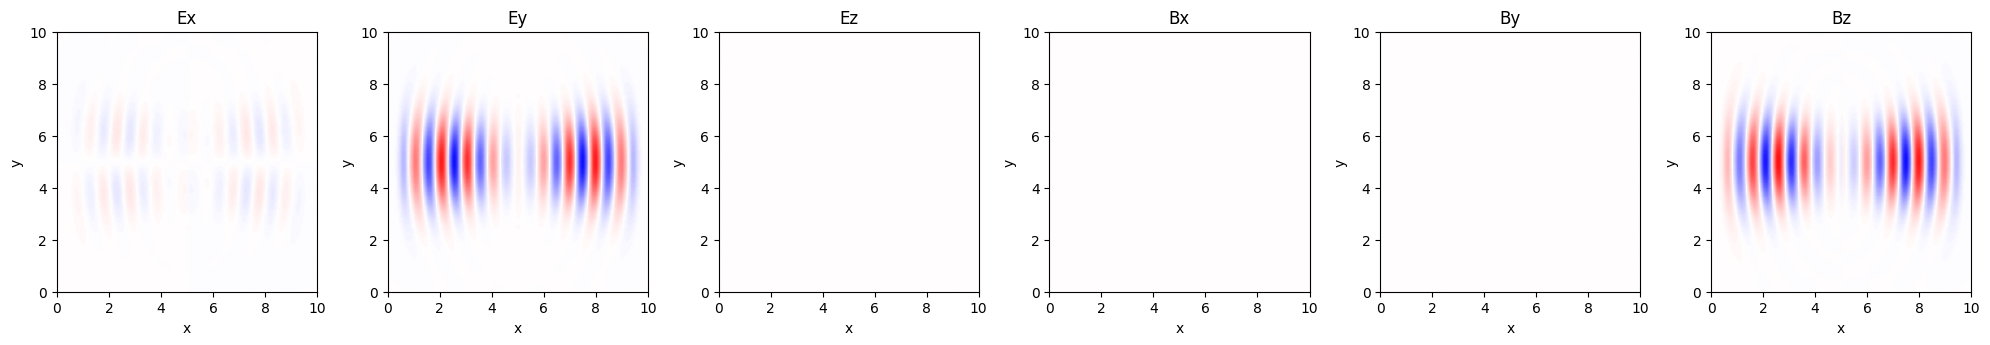

In [ ]:
#### YOUR CODE HERE ###########
# Copy the code of the previous exercise and modify it
###############################

#### POSSIBLE SOLUTION ########

def init_zero (Nx, Ny):
    Ex = np.zeros([Nx, Ny])
    Ey = np.zeros([Nx, Ny])
    Ez = np.zeros([Nx, Ny])
    Bx = np.zeros([Nx, Ny])
    By = np.zeros([Nx, Ny])
    Bz = np.zeros([Nx, Ny])

    return Ex, Ey, Ez, Bx, By, Bz

def m2d_sim (Nx, Ny, dx, dy, dt, xx, xxh, yy, yyh, steps, jfunc):
    Ex, Ey, Ez, Bx, By, Bz = init_zero(Nx, Ny)

    for i in tqdm(range(steps)):
        t = (i+0.5)*dt
        Jx, Jy, Jz = jfunc (Nx, Ny, t, xx, xxh, yy, yyh)
        Ex, Ey, Ez, Bx, By, Bz = evolve_E_B(Ex, Ey, Ez, Bx, By, Bz, Jx, Jy, Jz, dx, dy, dt)

    return Ex, Ey, Ez, Bx, By, Bz

def jfunc_gauss_x (Nx, Ny, t, xx = None, xxh = None, yy = None, yyh = None):
    Jx = np.zeros([Nx, Ny])
    Jy = np.zeros([Nx, Ny])
    Jz = np.zeros([Nx, Ny])

    xc = xx[int(Nx/2)]
    yc = yyh[int(Ny/2)]
    y1 = yyh[int(Ny/4)]
    y2 = yyh[int(3*Ny/4)]
    XX, YY = np.meshgrid(xx, yyh,indexing='ij')

    tc = 2.0

    Jy = np.sin(2.0*np.pi*t)*np.exp(-(t -tc)**2/3.0)*np.exp(-(YY-yc)**2/2)*(XX == xc)*(YY > y1)*(YY < y2)

    return Jx, Jy, Jz

def do_maxwell_2d_gaussian_test ():
    Nx = 200 + 1
    Ny = 200 + 1
    Lx = 10.0
    Ly = 10.0
    dx = Lx/Nx
    dy = Ly/Ny

    xx = np.linspace(0, Lx + dx, Nx)
    yy = np.linspace(0, Ly + dy, Ny)
    xxh = xx - dx*0.5
    yyh = yy - dy*0.5

    cfl = 0.95
    dt = cfl/np.sqrt(1/(dx**2) + 1/(dy**2))

    steps = 140

    print("Simulation")
    Ex1, Ey1, Ez1, Bx1, By1, Bz1 = m2d_sim (Nx, Ny, dx, dy, dt, xx, xxh, yy, yyh, steps, jfunc_gauss_x)

    fig, ax = plt.subplots(1,6, figsize=(20,4))

    F = [Ex1, Ey1, Ez1, Bx1, By1, Bz1]
    fn = ["Ex", "Ey", "Ez", "Bx", "By", "Bz"]

    for j in range (6):
        ax[j].set_title("{:}".format(fn[j]))
        ax[j].imshow(np.transpose(F[j]), vmin=-0.05, vmax=0.05, cmap="seismic", origin="lower", extent=[0, Lx, 0, Ly])
        ax[j].set_xlabel("x")
        ax[j].set_ylabel("y")

    plt.tight_layout()


do_maxwell_2d_gaussian_test()
###############################
